## Max Cut QAOA (Vanilla)

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib import cm
from ipywidgets import widgets, interact
from tqdm.auto import tqdm

n = 7
p = 3/8
seed = 42

rng = np.random.default_rng(seed)

#### Example Graph

In [2]:
from utils import (
    generate_graph,
    draw_init_graph,
    color_graph,
    draw_graph,
    mark_edges,
)

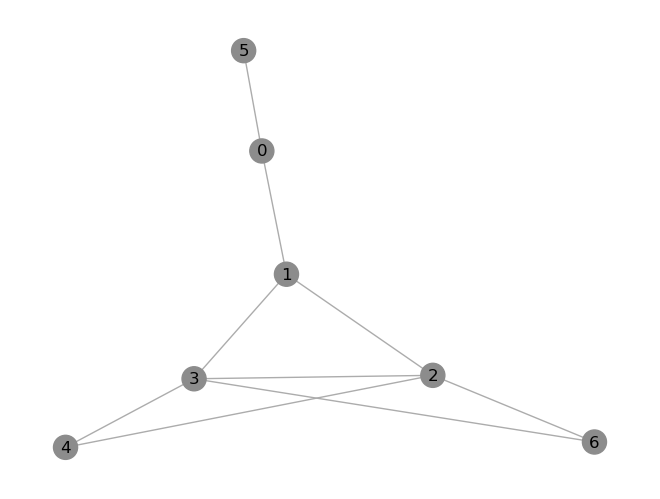

In [3]:
G = generate_graph(n, p)
edge_list = G.edges
draw_init_graph(G)

#### Brute force (classical)

In [4]:
from utils import brute_force

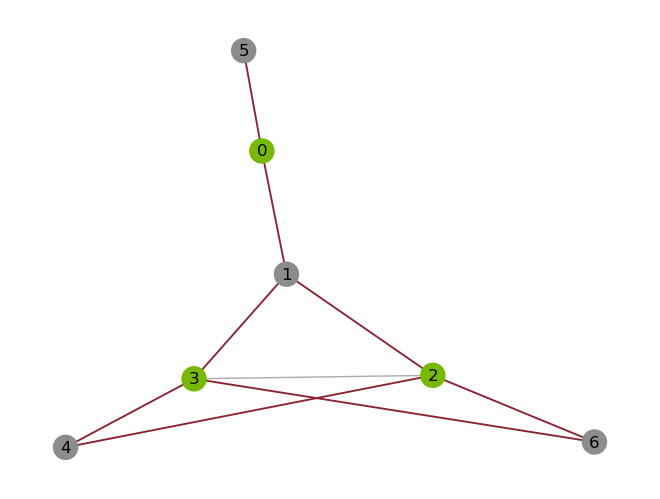

In [5]:
max_cut_value, max_cut_edges, max_subset = brute_force(G)
G = color_graph(G, max_subset, 1)
G = mark_edges(G, max_cut_edges)
draw_graph(G)

#### qaoa

In [6]:
import cudaq
from cudaq import spin
from cudaq.qis import *
from typing import List

# from utils import (
#     process_max_cut
# )

In [7]:
cudaq.set_target('nvidia-mgpu')
cudaq.set_random_seed(seed)

shots = 1000
layer_count = 1
parameter_count = 2 * layer_count

[warning] Target nvidia-mgpu: This target is deprecating. Please use the 'nvidia' target with option 'mgpu,fp64' by adding the command line option '--target-option mgpu,fp64' or passing it as cudaq.set_target('nvidia', option='mgpu,fp64') in Python. Please refer to CUDA-Q ]8;;https://nvidia.github.io/cuda-quantum/latest/using/backends/simulators.html#multi-node-multi-gpu\documentation]8;;\ for more information.


In [8]:
def max_cut_hamiltonian(sources, targets):
    ham = 0

    for i in range(len(sources)):
        qu = sources[i]
        qv = targets[i]
        ham += spin.z(qu) * spin.z(qv)
        ham -= spin.i(qu) * spin.i(qv)

    ham = ham / 2
    return ham

@cudaq.kernel
def problem(q0: cudaq.qubit, q1: cudaq.qubit, alpha: float):
    x.ctrl(q0, q1)
    rz(alpha * 2, q1)
    x.ctrl(q0, q1)

@cudaq.kernel
def mixer(qubit: cudaq.qubit, beta: float):
    rx(beta, qubit)

@cudaq.kernel
def qaoa(
    qubit_count: int,
    layer_count: int,
    edges_source: List[int],
    edges_target: List[int],
    n_edges: int,
    thetas: List[float]):

    qubits = cudaq.qvector(qubit_count)
    h(qubits)

    for i in range(layer_count):
        for edge in range(n_edges):
            qu = edges_source[edge]
            qv = edges_target[edge]
            problem(qubits[qu], qubits[qv], thetas[i])

        for q in range(qubit_count):
            mixer(qubits[q], thetas[i + layer_count])

In [9]:
nodes = list(G.nodes())
qubit_count = len(nodes)

qubit_source = list()
qubit_target = list()
n_edges = 0
for u, v in nx.edges(G):
    qubit_source.append(nodes.index(u))
    qubit_target.append(nodes.index(v))
    n_edges += 1

hamil = max_cut_hamiltonian(qubit_source, qubit_target)

In [10]:
# def update_graph(param1, param2):
#     parameters = [param1, param2]
    
#     counts = cudaq.sample(qaoa, qubit_count, layer_count, qubit_source, qubit_target, n_edges, parameters, shots_count=shots)
#     result = str(counts.most_probable())
#     attrs = {node: int(res) for node, res in enumerate(result)}
#     nx.set_node_attributes(G, attrs, 'color')

#     max_cut_value, max_cut_edges = process_max_cut(G)
#     mark_edges(G, max_cut_edges)
#     draw_graph(G, title=max_cut_value)

# param1_slider = widgets.FloatSlider(min=-np.pi, max=np.pi, step=0.1, value=np.random.uniform(-np.pi, np.pi))
# param2_slider = widgets.FloatSlider(min=-np.pi, max=np.pi, step=0.1, value=np.random.uniform(-np.pi, np.pi))

# interact(update_graph, param1=param1_slider, param2=param2_slider)

In [11]:
params1 = np.linspace(-np.pi, np.pi, 200)
params2 = np.linspace(-np.pi, np.pi, 200)
results = np.zeros((len(params1), len(params2)))

for i, p1 in enumerate(tqdm(params1)):
    for j, p2 in enumerate(params2):
        observation = cudaq.observe(
            qaoa,
            hamil,
            qubit_count,
            layer_count,
            qubit_source,
            qubit_target,
            n_edges,
            [p1, p2],
            shots_count=shots
        )
        
        results[i, j] = observation.expectation()

P1, P2 = np.meshgrid(params1, params2, indexing='ij')

  0%|          | 0/200 [00:00<?, ?it/s]

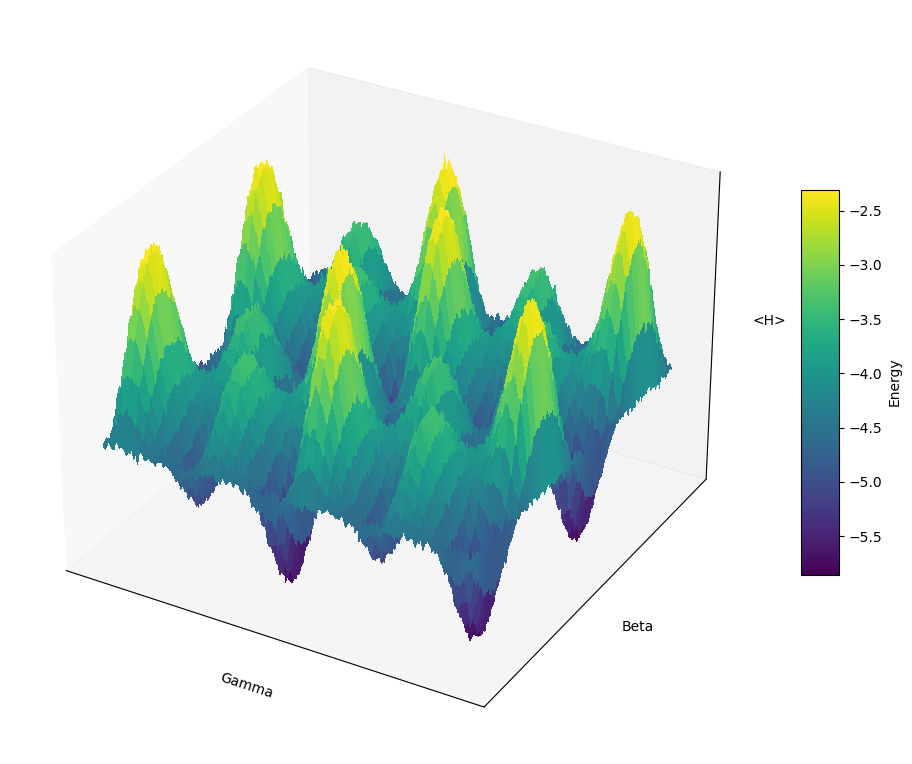

In [12]:
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    P1, 
    P2, 
    results, 
    cmap=cm.viridis,
    linewidth=0, 
    antialiased=False
)

ax.set_xlabel('Gamma')
ax.set_ylabel('Beta')
ax.set_zlabel('<H>')

ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Energy')

[]

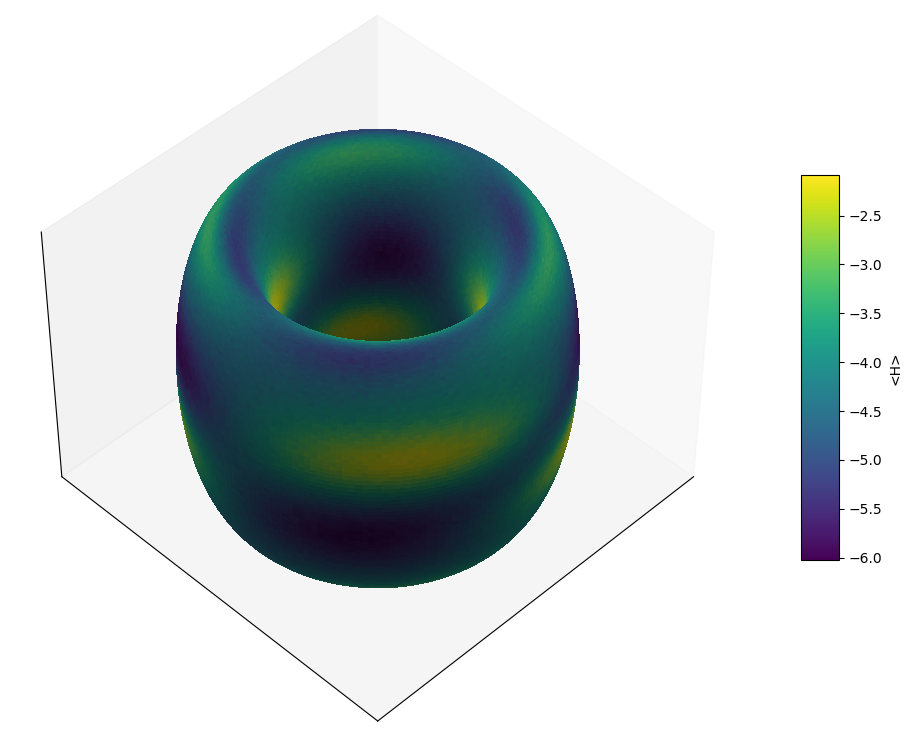

In [13]:
Theta, Phi = np.meshgrid(params1, params2, indexing='ij')

R = 3
r = 1

# torus
X = (R + r * np.cos(Theta)) * np.cos(Phi)
Y = (R + r * np.cos(Theta)) * np.sin(Phi)
Z = r * np.sin(Theta)

min_energy = np.min(results)
max_energy = np.max(results)
norm_energy = (results - min_energy) / (max_energy - min_energy)

colors = cm.viridis(norm_energy)

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, Y, Z, 
                       facecolors=colors, 
                       rstride=1, cstride=1, 
                       linewidth=0, 
                       shade=True,
                       antialiased=False)

m = cm.ScalarMappable(cmap=cm.viridis)
m.set_array(results)
cbar = plt.colorbar(m, ax=ax, shrink=0.5, aspect=10, pad=0.08)
cbar.set_label('<H>')

ax.view_init(elev=45, azim=45)

ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

In [14]:
ham = 0

for i in range(n_edges):
    qu = qubit_source[i]
    qv = qubit_target[i]
    ham += spin.z(qu) * spin.z(qv)

In [15]:
results = np.zeros((len(params1), len(params2)))

for i, p1 in enumerate(tqdm(params1)):
    for j, p2 in enumerate(params2):
        observation = cudaq.observe(
            qaoa,
            ham,
            qubit_count,
            layer_count,
            qubit_source,
            qubit_target,
            n_edges,
            [p1, p2],
            shots_count=shots
        )
        
        results[i, j] = observation.expectation()

P1, P2 = np.meshgrid(params1, params2, indexing='ij')

  0%|          | 0/200 [00:00<?, ?it/s]

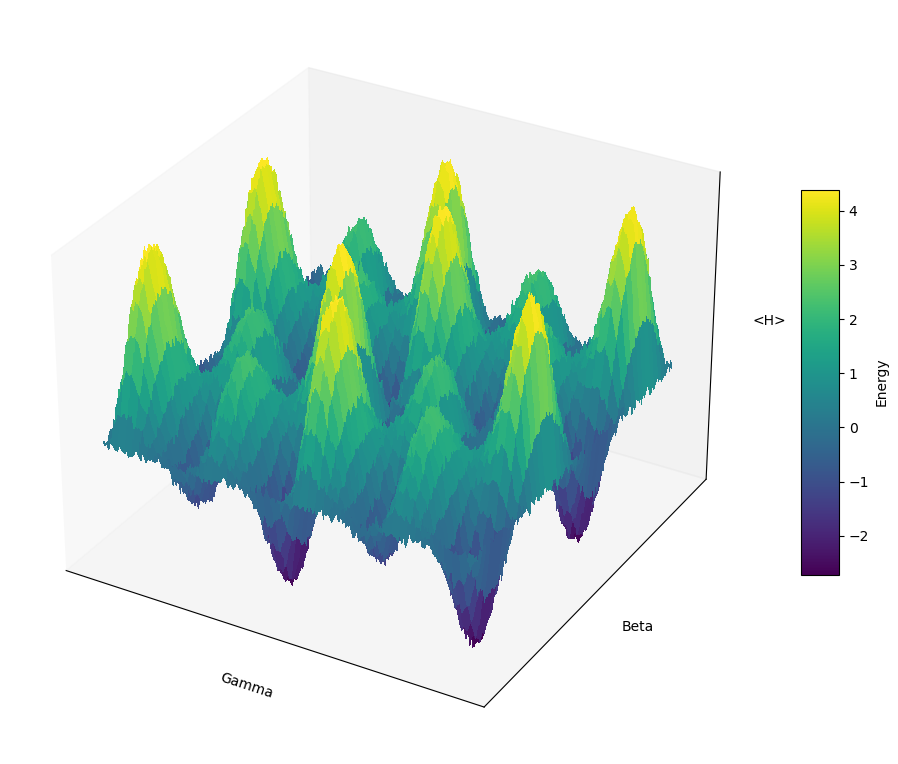

In [16]:
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    P1, 
    P2, 
    results, 
    cmap=cm.viridis,
    linewidth=0, 
    antialiased=False
)

ax.set_xlabel('Gamma')
ax.set_ylabel('Beta')
ax.set_zlabel('<H>')

ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Energy')

[]

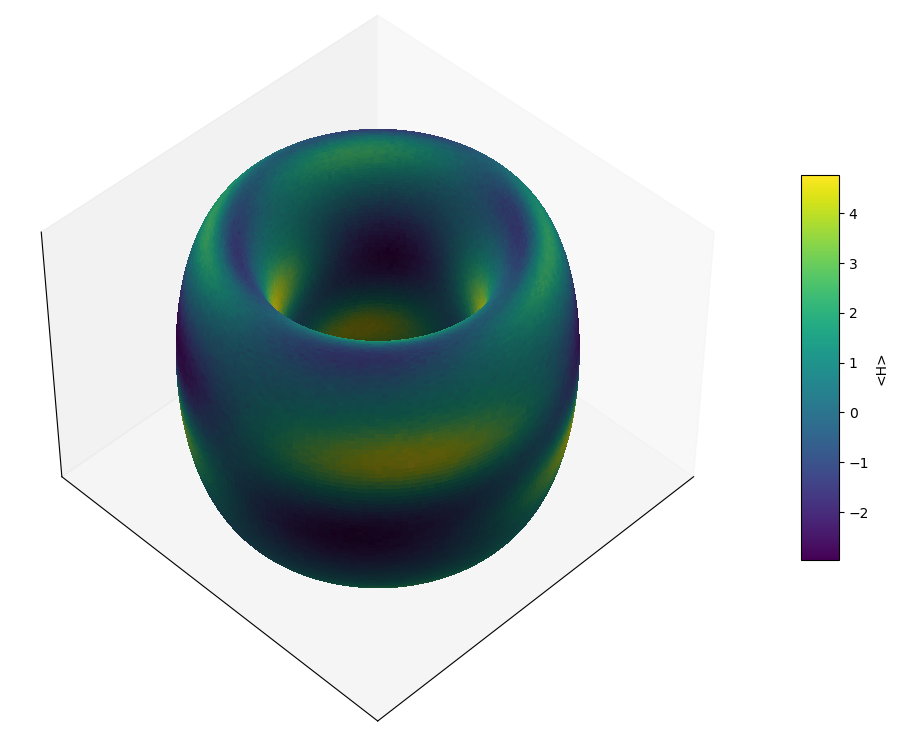

In [17]:
Theta, Phi = np.meshgrid(params1, params2, indexing='ij')

R = 3
r = 1

# torus
X = (R + r * np.cos(Theta)) * np.cos(Phi)
Y = (R + r * np.cos(Theta)) * np.sin(Phi)
Z = r * np.sin(Theta)

min_energy = np.min(results)
max_energy = np.max(results)
norm_energy = (results - min_energy) / (max_energy - min_energy)

colors = cm.viridis(norm_energy)

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, Y, Z, 
                       facecolors=colors, 
                       rstride=1, cstride=1, 
                       linewidth=0, 
                       shade=True,
                       antialiased=False)

m = cm.ScalarMappable(cmap=cm.viridis)
m.set_array(results)
cbar = plt.colorbar(m, ax=ax, shrink=0.5, aspect=10, pad=0.08)
cbar.set_label('<H>')

ax.view_init(elev=45, azim=45)

ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

In [ ]:
# FUCK MY GPU